In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram,linkage

In [30]:
df=pd.read_csv("Data.csv")
print(f"veri boyutu:{df.shape}")
df.info()

veri boyutu:(4600, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_

In [23]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988470,563834.702545,0.0,322875.0000,460943.460,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.0000,3.000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.7500,2.250,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.0000,1980.000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.7500,7683.000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.0000,1.500,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.0000,0.000,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.0000,0.000,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.0000,3.000,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.0000,1590.000,2300.00,9410.0


In [25]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [26]:
df.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
4595,2014-07-09,308166.67,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,204.08
4596,2014-07-09,534333.33,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,365.98
4597,2014-07-09,416904.17,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,138.51
4598,2014-07-10,203400.00,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,97.32
4599,2014-07-10,220600.00,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,148.05


In [37]:
df_1 = df.select_dtypes(include=[np.number])

AttributeError: 'list' object has no attribute 'info'

In [38]:
#df.set_index("date",inplace=True)
imputer =SimpleImputer(strategy="mean")
df_imputed =pd.DataFrame(imputer.fit_transform(df_1),columns=df_1.columns,index=df_1.index)
print(f"Eksik deger kaldi mi: {df_imputed.isnull().sum().sum()}")

Eksik deger kaldi mi: 0


In [39]:
scaler =StandardScaler()
X_scaled =scaler.fit_transform(df_imputed)
df_scaled =pd.DataFrame(X_scaled,columns=df_imputed.columns,index=df_imputed.index)
df_scaled.head(2)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
date,,,,,,,,,,,,,,
2014-05-02,-0.423864,-0.441122,-0.843204,-0.829971,-0.193434,-0.022416,-0.085004,-0.309194,-0.667112,-0.565224,-0.672464,-0.531014,1.221670,-0.090348
2014-05-02,3.249598,1.759705,0.432802,1.568528,-0.161718,0.906555,-0.085004,4.830079,2.286416,1.789559,-0.069128,-1.674693,-0.825693,1.083391


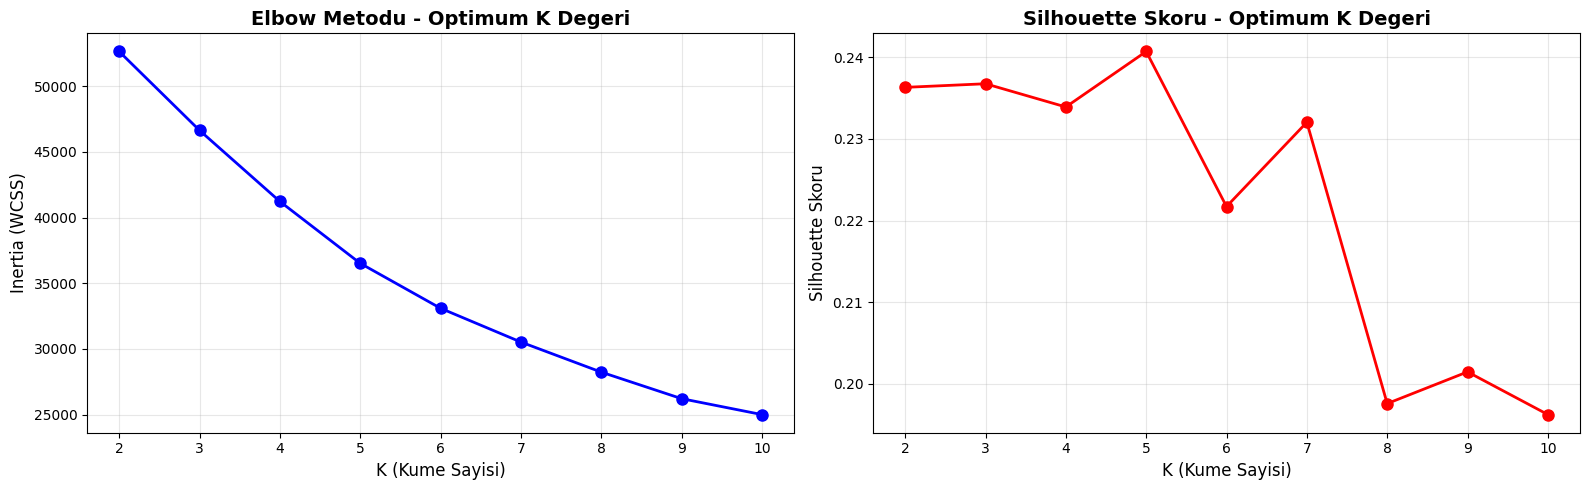

En iyi silhoutte skoru: 0.2407
Optimum K degeri: 5


In [40]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Gorsellestirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhoutte skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K degeri: {optimal_k}')

In [95]:
optimal_k = 3  # Elbow ve silhouette analizine gore
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kumeleme Sonuclari:
Kume sayisi: 3
Silhouette Skoru: 0.2368
Davies-Bouldin Indeksi: 1.1587
Calinski-Harabasz Skoru: 875.0699

Kume dagilimi:
0    1990
1    2609
2       1
Name: count, dtype: int64


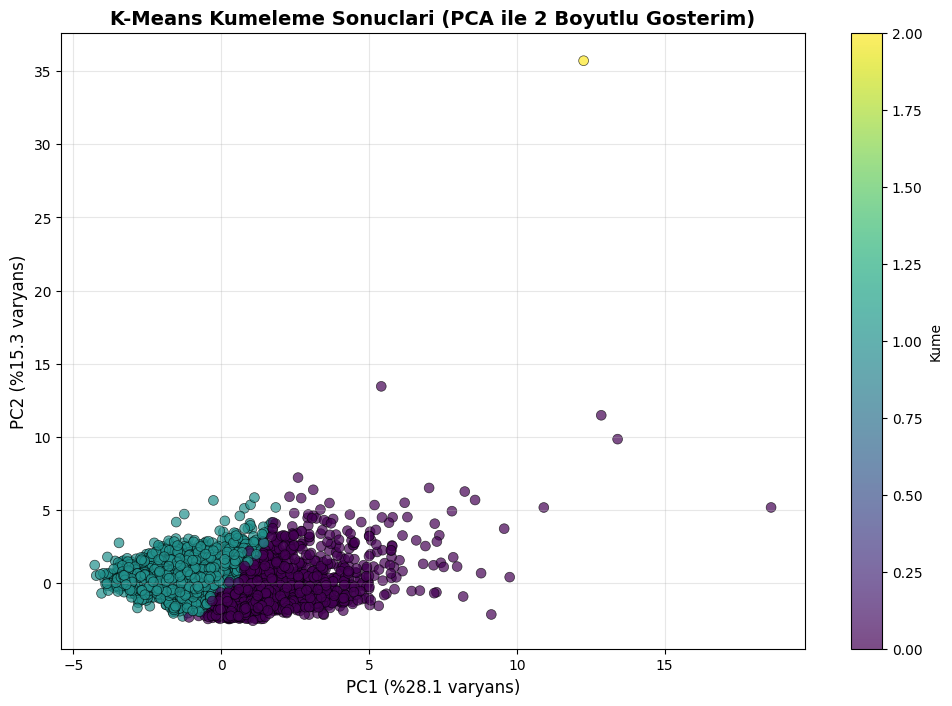

In [83]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

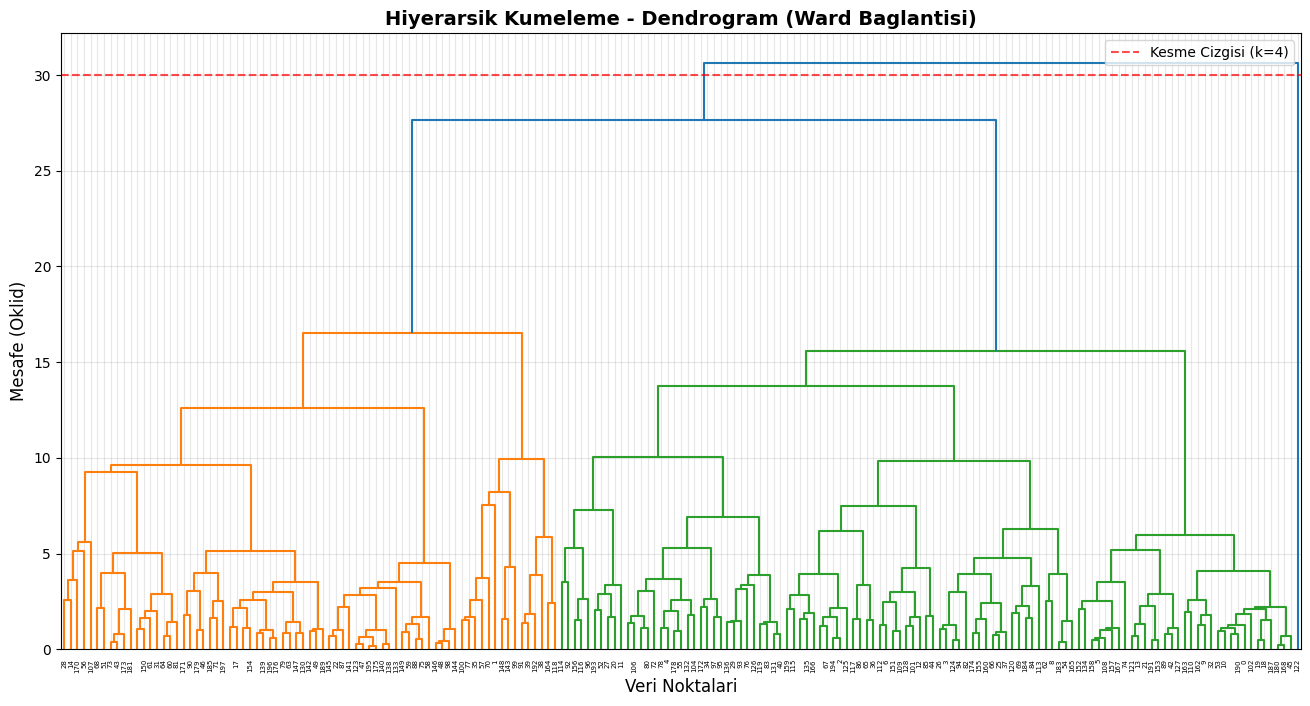

In [84]:
plt.figure(figsize=(16, 8))
linked = linkage(X_scaled[:200], method='ward')  # Gorsellestirme icin 200 ornek
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarsik Kumeleme - Dendrogram (Ward Baglantisi)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari', fontsize=12)
plt.ylabel('Mesafe (Oklid)', fontsize=12)
plt.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Kesme Cizgisi (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [96]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print('Hiyerarsik Kumeleme (Agglomerative) Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Baglanti yontemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())

Hiyerarsik Kumeleme (Agglomerative) Sonuclari:
Kume sayisi: 3
Baglanti yontemi: ward
Silhouette Skoru: 0.2161
Davies-Bouldin Indeksi: 1.2916
Calinski-Harabasz Skoru: 756.0460

Kume dagilimi:
0    1919
1    2680
2       1
Name: count, dtype: int64


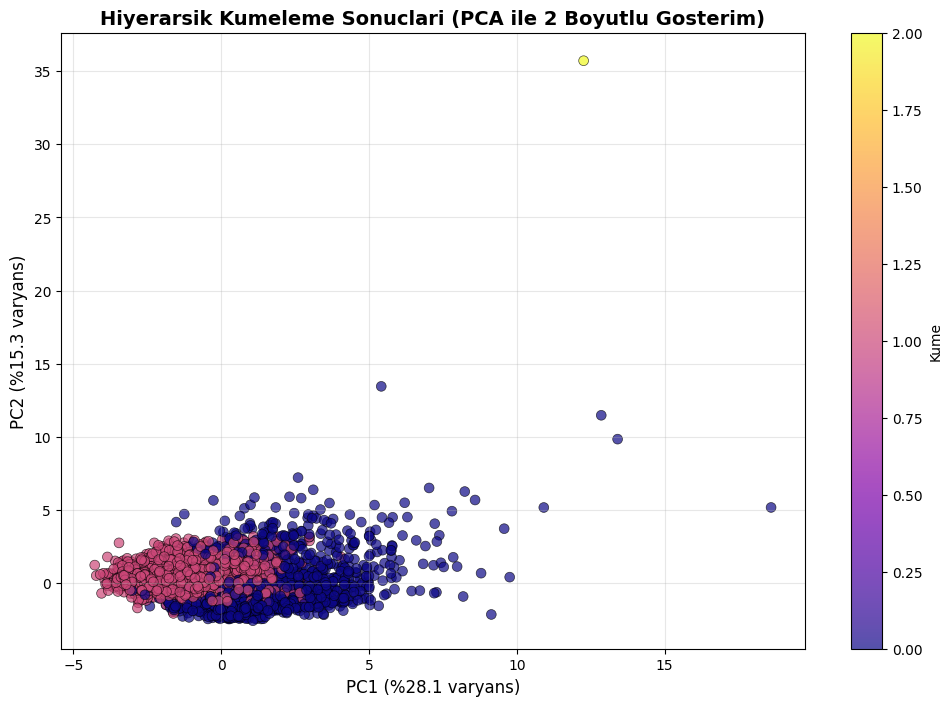

In [97]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [92]:
optimal_k = 5 # Elbow ve silhouette analizine gore
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kumeleme Sonuclari:
Kume sayisi: 5
Silhouette Skoru: 0.2407
Davies-Bouldin Indeksi: 1.1478
Calinski-Harabasz Skoru: 877.0270

Kume dagilimi:
0    1646
1    2316
2     604
3      33
4       1
Name: count, dtype: int64


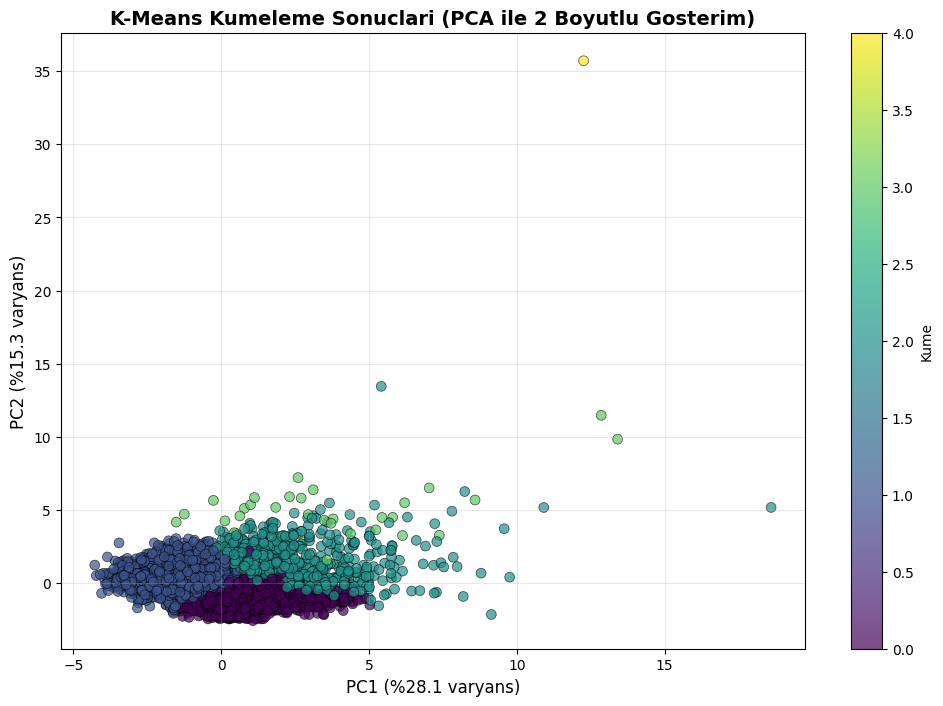

In [79]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

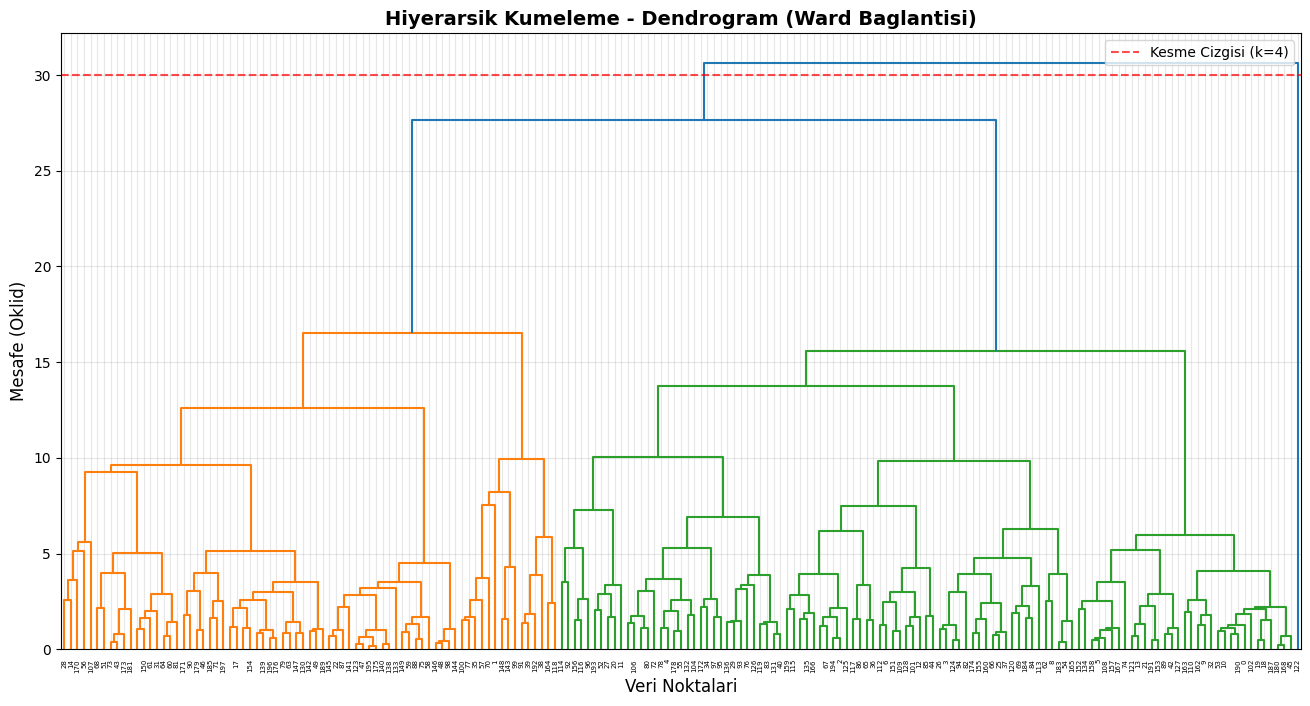

In [80]:
plt.figure(figsize=(16, 8))
linked = linkage(X_scaled[:200], method='ward')  # Gorsellestirme icin 200 ornek
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarsik Kumeleme - Dendrogram (Ward Baglantisi)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari', fontsize=12)
plt.ylabel('Mesafe (Oklid)', fontsize=12)
plt.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Kesme Cizgisi (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [93]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print('Hiyerarsik Kumeleme (Agglomerative) Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Baglanti yontemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())

Hiyerarsik Kumeleme (Agglomerative) Sonuclari:
Kume sayisi: 5
Baglanti yontemi: ward
Silhouette Skoru: 0.2153
Davies-Bouldin Indeksi: 1.1907
Calinski-Harabasz Skoru: 740.3414

Kume dagilimi:
0    2680
1     376
2       1
3    1512
4      31
Name: count, dtype: int64


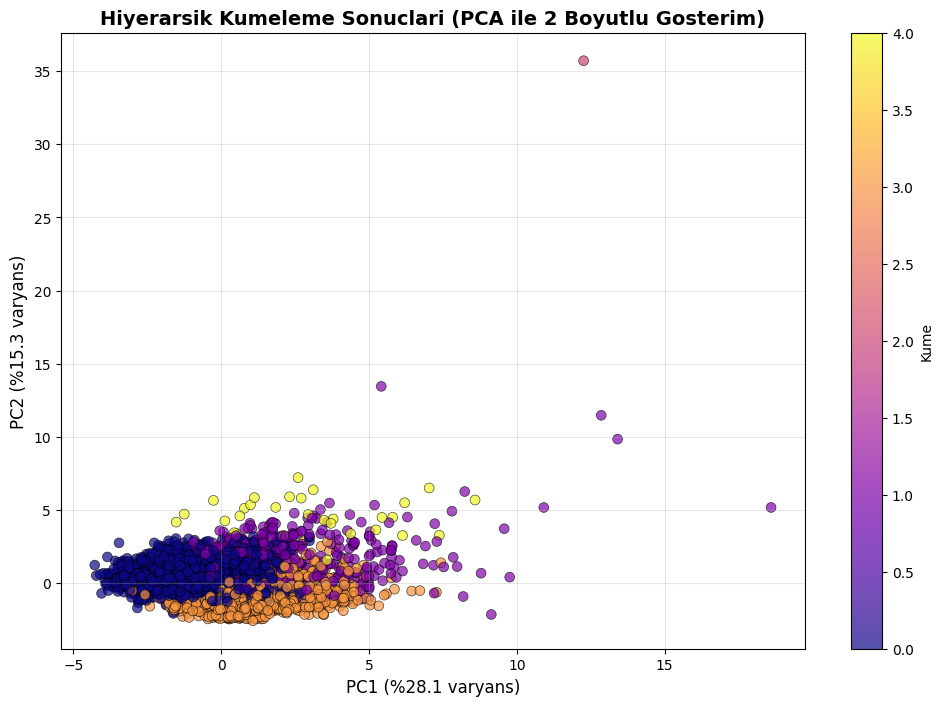

In [94]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

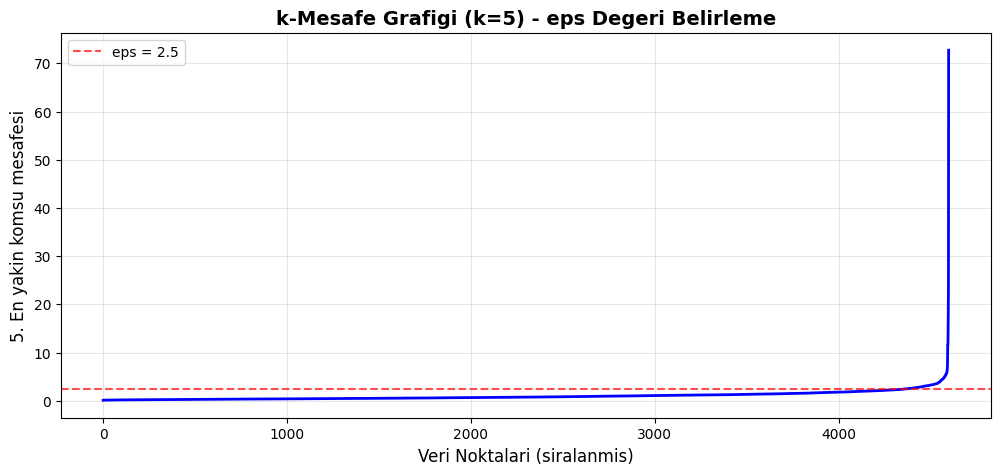

In [100]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=2.5, color='r', linestyle='--', alpha=0.7, label='eps = 2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [101]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kumeleme Sonuclari:')
print(f'eps: 2.5, min_samples: 5')
print(f'Olusan kume sayisi: {n_clusters_db}')
print(f'Gurultu (aykiri deger) sayisi: {n_noise}')
print(f'Gurultu orani: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(X_scaled, dbscan_labels):.4f}')
    print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, dbscan_labels):.4f}')

print(f'\nKume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())


DBSCAN Kumeleme Sonuclari:
eps: 2.5, min_samples: 5
Olusan kume sayisi: 1
Gurultu (aykiri deger) sayisi: 155
Gurultu orani: 3.37%

Kume dagilimi:
-1     155
 0    4445
Name: count, dtype: int64


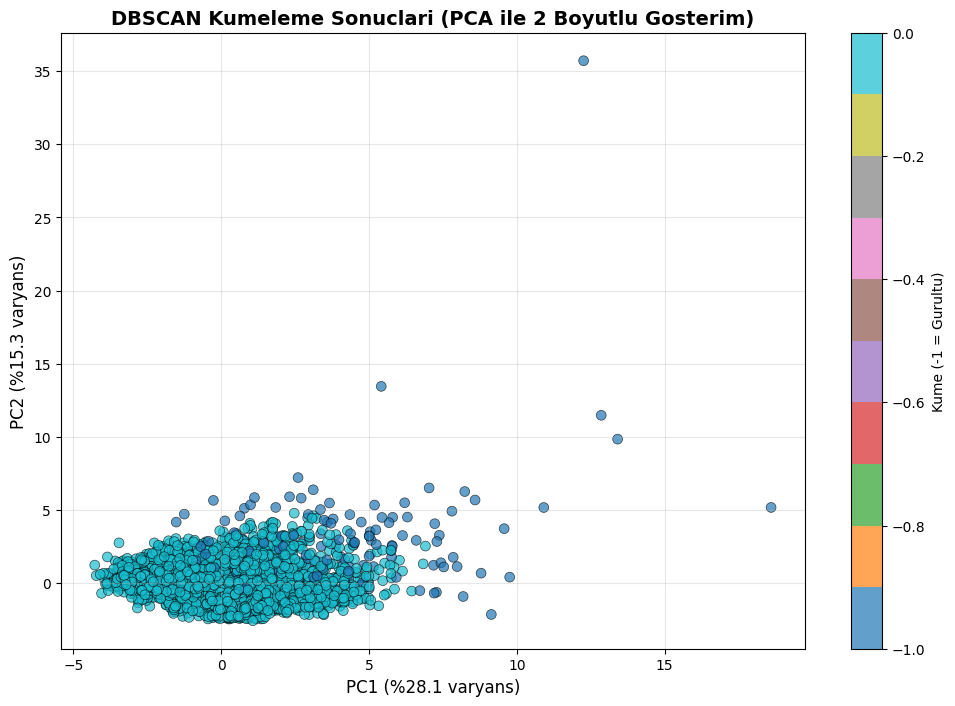

In [102]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

***Decision Tree***

In [139]:
import random
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (accuracy_score,classification_report,ConfusionMatrixDisplay,RocCurveDisplay)
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_wine

In [141]:
SEED = 42
np.random.seed(SEED)

data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

In [142]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
dt_grid= GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                      param_grid={
                          "criterion":["gini","entropy"],
                          "splitter":["best","random"],
                          "max_depth":[3,4,5,6,8,None],
                          "min_samples_leaf" :[1,2,5,10]
                      },
                      cv=cv ,scoring="accuracy",n_jobs=-1)
dt_grid.fit(X_train,y_train)
dt=dt_grid.best_estimator_
print("En iyi parametre:", dt_grid.best_params_)

En iyi parametre: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'splitter': 'random'}


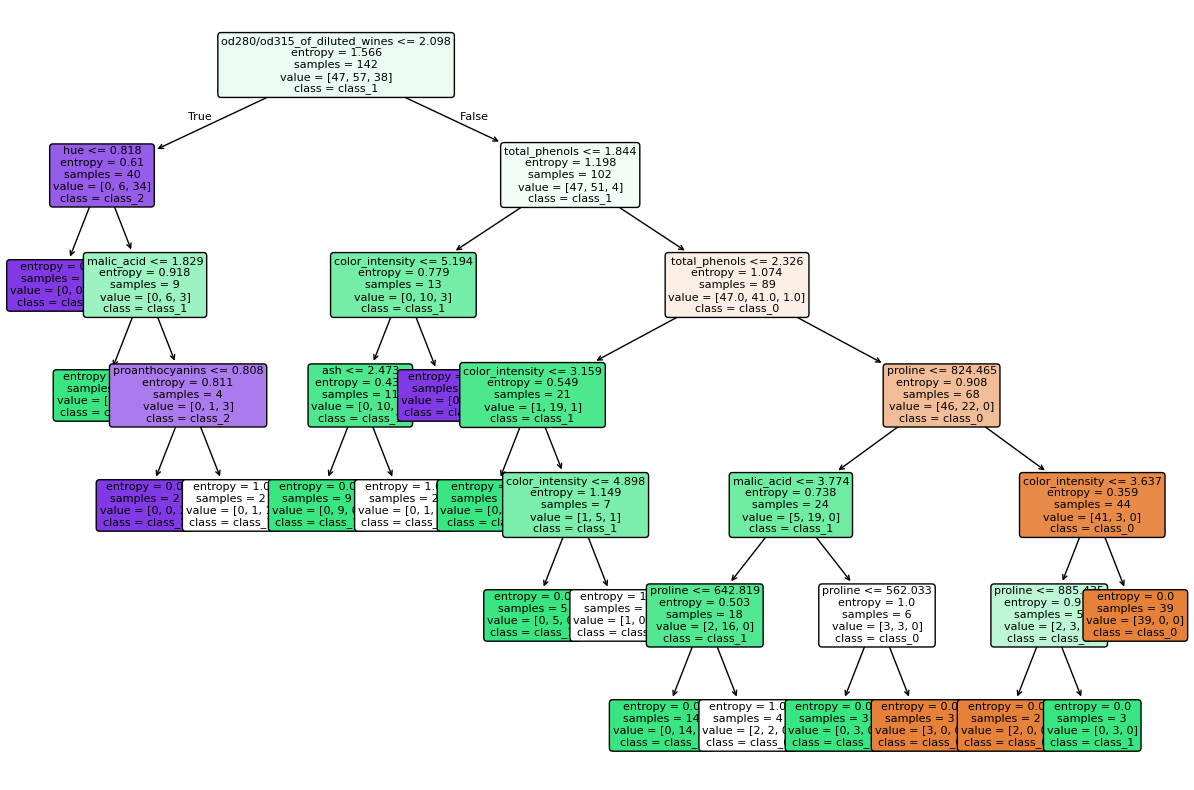

In [143]:
plt.figure(figsize=(15,10))
plot_tree(dt,feature_names=data.feature_names,class_names=data.target_names,
          filled=True,rounded= True, max_depth= 8, fontsize =8)

plt.show()

In [144]:
from sklearn.ensemble import RandomForestClassifier
rf_grid= GridSearchCV(RandomForestClassifier(random_state=SEED),
                      param_grid={
                          "n_estimators":[100,200],
                          "max_depth":[5,7],
                          "min_samples_leaf" :[1,2],
                          "min_samples_split":[2,5],
                          "max_features":["sqrt","log2"],
                          "criterion":["gini","entropy"],
                          "bootstrap":[True,False]
                      },
                      cv=cv ,scoring="accuracy",n_jobs=-1,verbose =3)
rf_grid.fit(X_train,y_train)
rf=rf_grid.best_estimator_
print("En iyi parametre:", rf_grid.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
En iyi parametre: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [145]:
for name,model in [("Decision Tree" ,dt),("Random Forest",rf)]:
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    cv_scores=cross_val_score(model,X_train,y_train,cv=cv,scoring="accuracy")
    print(f"========{"Test"}========")
    print(f"Test doğruluğu:{accuracy_score(y_test,y_pred)}")
    print(f"Ortalama 5 katlı CV doğruluğu:{np.mean(cv_scores)}")

========Test========
Test doğruluğu:0.9166666666666666
Ortalama 5 katlı CV doğruluğu:0.9091133004926109
========Test========
Test doğruluğu:1.0
Ortalama 5 katlı CV doğruluğu:0.9862068965517242


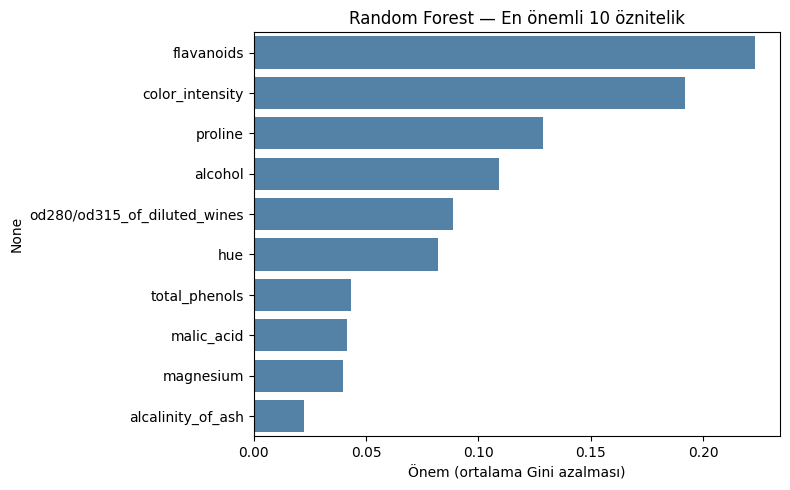

Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png


In [146]:
imp = pd.Series(rf.feature_importances_, index=data.feature_names).nlargest(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.xlabel("Önem (ortalama Gini azalması)")
plt.title("Random Forest — En önemli 10 öznitelik")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png")